# PyTorch Workflow

Let's explore an end to end workflow

In [2]:
what_were_covering = {1:'data (prepare and load)',
                      2:'build a model',
                      3:'fit the model',
                      4:'maing predictions',
                      5:'saving and loading a model',
                      6:'put it all together'}

In [3]:
what_were_covering

{1: 'data (prepare and load)',
 2: 'build a model',
 3: 'fit the model',
 4: 'maing predictions',
 5: 'saving and loading a model',
 6: 'put it all together'}

In [4]:
import torch
from torch import nn
import matplotlib.pyplot as plt

#Check Pytorch version
torch.__version__

'2.13.0+cpu'

## 1. Data Preparing and Loading

In [5]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create 
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1) 
y = weight*X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

# Creating test and train split

In [6]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

"Visualize, visualize, visualize"

In [7]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [8]:
def plot_predictions(train_data=X_train,
                     train_labels = y_train,
                     test_data=X_test,
                     test_labels = y_test,
                     predictions = None):
    plt.figure(figsize=(10,7))

    plt.scatter(train_data,train_labels, c="b",
                s=4, label="Training data")
    plt.scatter(test_data,test_labels, c="g", s=4,
                label="Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions, c="r",
                    s=4, label="Predictions")
    plt.legend(prop={"size":14})

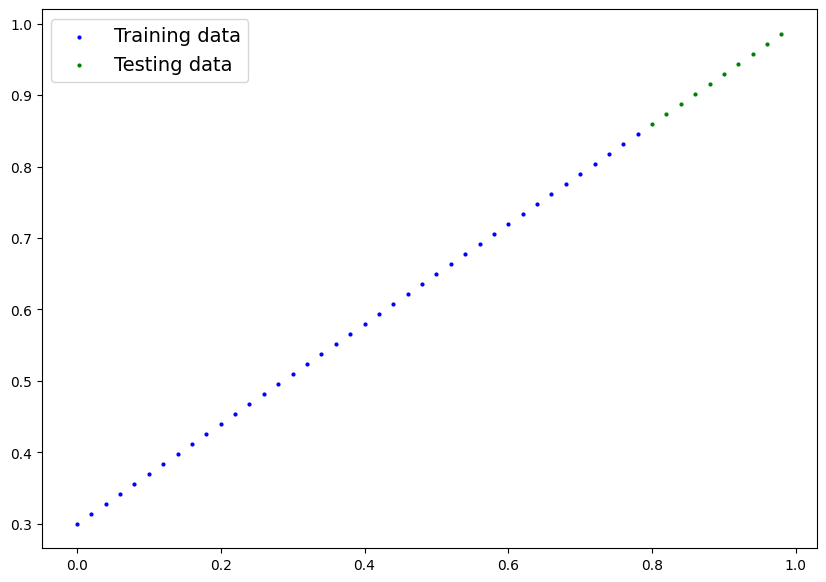

In [9]:
plot_predictions()

In [10]:
# Build a model
# Our model starts with random values (weight & bias) then updates values to represent real values overtime
# Uses gradient descent and backpropagation
class LinearRegressionModel(nn.Module): #<- almost everything inherits from nn.module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad = True,
                                                dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad = True,
                                             dtype = torch.float32))
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights *x + self.bias
        


### PyTorch Model building essentials

* torch.nn - contains all of the buildings for computational graphs ( a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overrite forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of our PyTorch model



In [11]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a sublcass of nn.module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [13]:
# Making predictions
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

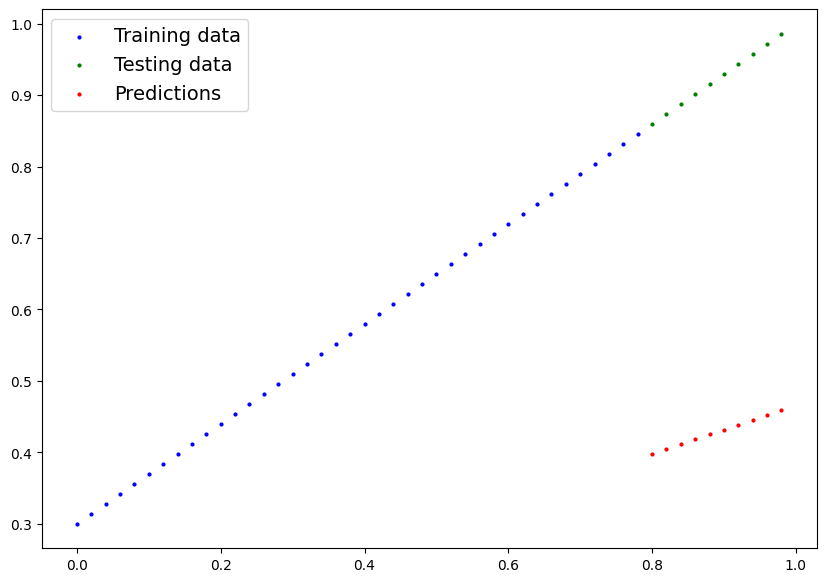

In [14]:
plot_predictions(predictions=y_preds)

In [15]:
# Train the model:

#First need to use a loss function to evaluate output
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD (params = model_0.parameters(),
                             lr = 0.01) # lr = learning rate = possibly the most important hyperparameter

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need:
0. Loop through the data
1. Forward pass( this involves data moving through our model's `forward()` functions to make predictions on data - forward propagation)
2. calculate the loss
3. Optimizer zero grad
4. loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to loss
5. Optimizer step


In [17]:
# an epoch is one loop through the data...
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []
### Training
# 0. Loop through the data
for epoch in range(epochs):
    #Set the model to training mode
    model_0.train() # train mode in PyTorch Set all parameters to 

    # 1.Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred,y_train)
    # print(f"loss:{loss}")

    #3 Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_0.eval() #Turns off different settings in the model not needed for evaluation/testing (dropout/batchnorm layers)
    with torch.inference_mode(): # turns off gradient tracking and a couple more things behind the scenes
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")


    # # Print out model _state_dict()
    # print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | Test loss: 0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | Test loss: 0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | Test loss: 0.06473556160926819
Epoch: 100 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
Epoch: 110 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
Epoch: 120 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
Epoch: 130 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
Ep

In [18]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

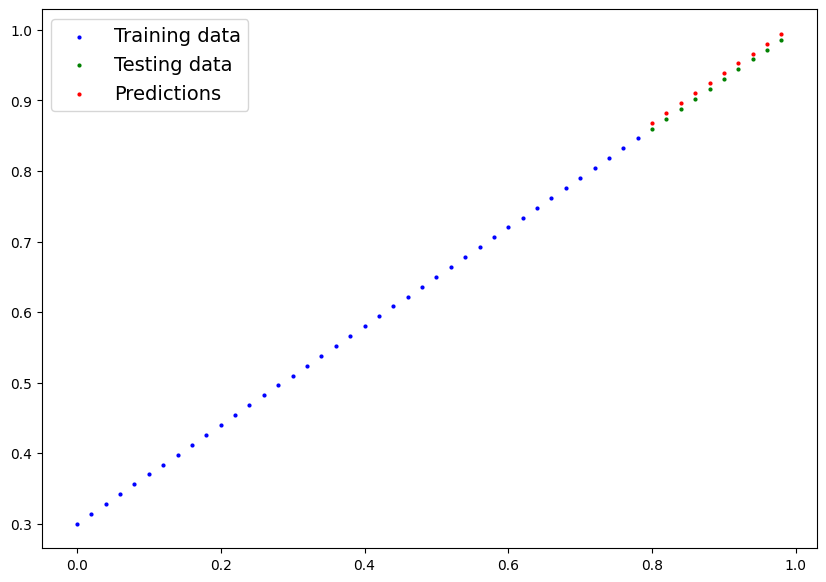

In [19]:
plot_predictions(predictions=y_preds_new)

In [20]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

C:\Users\jdata\AppData\Local\Temp\ipykernel_24424\1103371914.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  plt.plot(epoch_count, torch.tensor(loss_values).detach().numpy(), label = "Train loss")


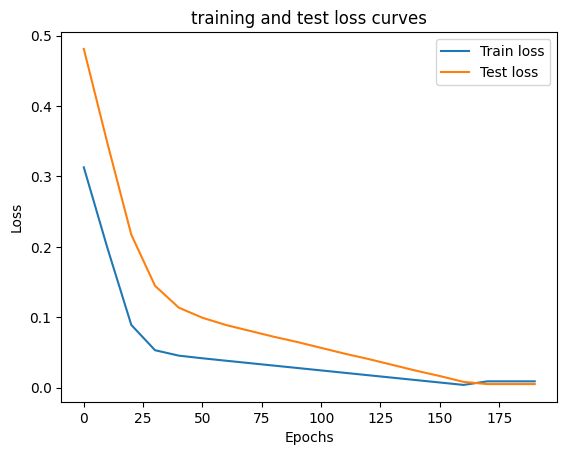

In [21]:
import numpy as np
plt.plot(epoch_count, torch.tensor(loss_values).detach().numpy(), label = "Train loss")
plt.plot(epoch_count, torch.tensor(test_loss_values).detach().numpy(), label = "Test loss")
plt.title("training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## Saving a model in PyTorch

There are three main methods to save and load models
1. torch.save() - saves model in pickle format
2. torch.load() - loads saved models
3. torch.nn.Module.load_state_dict() - this allows us to load a model's saved state dictionary 

In [22]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_0.state_dict(),f= MODEL_SAVE_PATH)

In [23]:
!ls -l models

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [24]:
## Loading a PyTorch model
loaded_model_0 = LinearRegressionModel()

#Load the saved state dict of model_0

loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [25]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [26]:
# Make some predictions
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [27]:
# Make some predictions
model_0.eval()
with torch.inference_mode():
    model_preds = model_0(X_test)

model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [28]:
## Putting it all together
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [29]:
# Create some data using the linear regression formula 
weight = 0.7
bias = 0.3

# create a range 
start = 0
end = 1
step = 0.02

#create X and Y
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [30]:
#split data
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

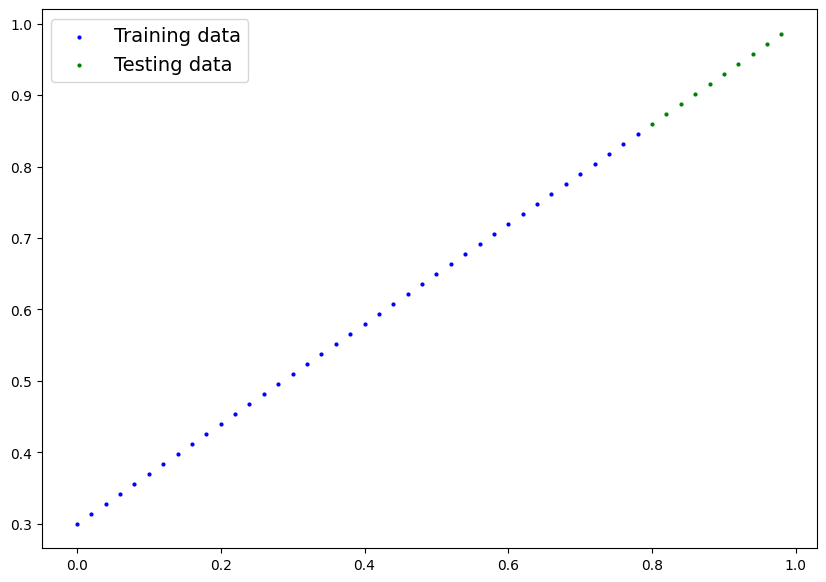

In [31]:
plot_predictions(X_train,y_train,X_test, y_test)

In [32]:
## 6.2 Building a PyTorch Linear Model
class LinearRegressionModelv2(nn.Module):
    def __init__(self):
        super().__init__()
        # Uuse nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelv2()
model_1, model_1.state_dict()

(LinearRegressionModelv2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### 6.3 Training

We need
- Loss function
- Optimizer
- Training loop
- Testing loop

In [33]:
# Set the model to use the target device
next(model_1.parameters()).device

loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.01)

In [34]:
torch.manual_seed(42)

epochs = 200

# Put data on the same device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [35]:

for epoch in range(epochs):
    model_1.train()

    #forward pass
    y_pred = model_1(X_train)

    #Calcualte loss
    loss = loss_fn(y_pred, y_train)

    # Optimizer zero grad
    optimizer.zero_grad()

    # Perform backpropagation
    loss.backward()

    # Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {"loss"}")

Epoch: 0 | Loss: loss
Epoch: 10 | Loss: loss
Epoch: 20 | Loss: loss
Epoch: 30 | Loss: loss
Epoch: 40 | Loss: loss
Epoch: 50 | Loss: loss
Epoch: 60 | Loss: loss
Epoch: 70 | Loss: loss
Epoch: 80 | Loss: loss
Epoch: 90 | Loss: loss
Epoch: 100 | Loss: loss
Epoch: 110 | Loss: loss
Epoch: 120 | Loss: loss
Epoch: 130 | Loss: loss
Epoch: 140 | Loss: loss
Epoch: 150 | Loss: loss
Epoch: 160 | Loss: loss
Epoch: 170 | Loss: loss
Epoch: 180 | Loss: loss
Epoch: 190 | Loss: loss


In [36]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [37]:
# Making and evaluating predictions
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

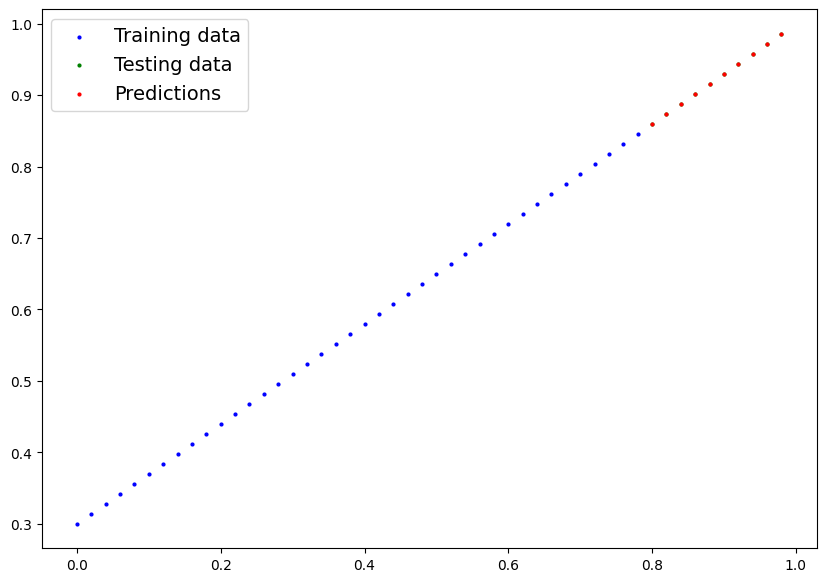

In [38]:
plot_predictions(predictions=y_preds)

In [39]:
### Save and load a model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_model_1.pth


In [40]:
# Load a PyTorch model
loaded_model_1 = LinearRegressionModelv2()

loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [41]:
loaded_model_1.to(device)

LinearRegressionModelv2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [42]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [43]:
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)




In [111]:
# Create dataset
start = 0
stop = 10
step = 0.2

m = 0.2
b = 0.4

X = torch.tensor(np.arange(start,stop,step), dtype =torch.float32).unsqueeze(dim=1)
y = torch.tensor(X*m + b, dtype = torch.float32)

C:\Users\jdata\AppData\Local\Temp\ipykernel_24424\2867334692.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(X*m + b, dtype = torch.float32)


In [105]:
split = int(len(X)*0.8)


In [112]:
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [107]:
y

tensor([[[0.4000]],

        [[0.4400]],

        [[0.4800]],

        [[0.5200]],

        [[0.5600]],

        [[0.6000]],

        [[0.6400]],

        [[0.6800]],

        [[0.7200]],

        [[0.7600]],

        [[0.8000]],

        [[0.8400]],

        [[0.8800]],

        [[0.9200]],

        [[0.9600]],

        [[1.0000]],

        [[1.0400]],

        [[1.0800]],

        [[1.1200]],

        [[1.1600]],

        [[1.2000]],

        [[1.2400]],

        [[1.2800]],

        [[1.3200]],

        [[1.3600]],

        [[1.4000]],

        [[1.4400]],

        [[1.4800]],

        [[1.5200]],

        [[1.5600]],

        [[1.6000]],

        [[1.6400]],

        [[1.6800]],

        [[1.7200]],

        [[1.7600]],

        [[1.8000]],

        [[1.8400]],

        [[1.8800]],

        [[1.9200]],

        [[1.9600]],

        [[2.0000]],

        [[2.0400]],

        [[2.0800]],

        [[2.1200]],

        [[2.1600]],

        [[2.2000]],

        [[2.2400]],

        [[2.2

In [57]:
plt.figure(figsize=(10,7))

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

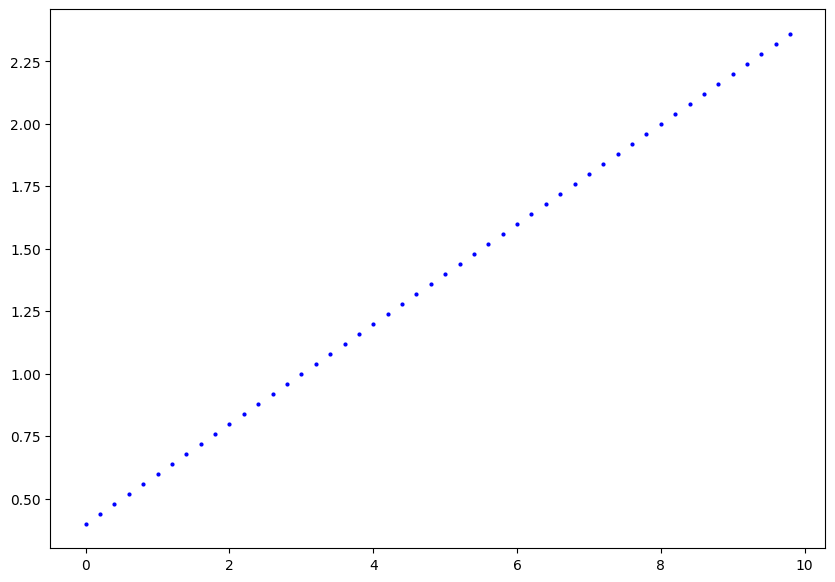

In [58]:
plt.figure(figsize=(10,7))
plt.scatter(X, y, c="b",
            s=4, label="Training data")
plt.show()

In [125]:
class LinearRegressionModelv3(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

model_3 = LinearRegressionModelv3()

In [126]:
model_3.state_dict

<bound method Module.state_dict of LinearRegressionModelv3(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)>

In [127]:
loss_fn = nn.L1Loss()


In [128]:
model_3.parameters

<bound method Module.parameters of LinearRegressionModelv3(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)>

In [129]:
optimizer = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.01)

In [130]:
model_3.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.8692]])),
             ('linear_layer.bias', tensor([0.1872]))])

In [131]:
EPOCHS = 300

for i in range(EPOCHS):
    model_3.train()

    y_pred = model_3(X_train)

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()

    with torch.inference_mode():

        test_pred = model_3(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if EPOCHS % 10 == 0:
        print(f"EPOCHS: {i}, loss: {loss}, test_loss: {test_loss} ")

EPOCHS: 0, loss: 2.411616563796997, test_loss: 5.387795448303223 
EPOCHS: 1, loss: 2.252195358276367, test_loss: 5.032585144042969 
EPOCHS: 2, loss: 2.0927743911743164, test_loss: 4.677374362945557 
EPOCHS: 3, loss: 1.9342952966690063, test_loss: 4.3244452476501465 
EPOCHS: 4, loss: 1.7773014307022095, test_loss: 3.971514940261841 
EPOCHS: 5, loss: 1.6203075647354126, test_loss: 3.6185851097106934 
EPOCHS: 6, loss: 1.4634888172149658, test_loss: 3.2688255310058594 
EPOCHS: 7, loss: 1.3096327781677246, test_loss: 2.919065475463867 
EPOCHS: 8, loss: 1.155776858329773, test_loss: 2.569305181503296 
EPOCHS: 9, loss: 1.0035399198532104, test_loss: 2.2236056327819824 
EPOCHS: 10, loss: 0.8541972041130066, test_loss: 1.8828554153442383 
EPOCHS: 11, loss: 0.7091225385665894, test_loss: 1.5479453802108765 
EPOCHS: 12, loss: 0.5696377754211426, test_loss: 1.219765543937683 
EPOCHS: 13, loss: 0.4372866153717041, test_loss: 0.9077154397964478 
EPOCHS: 14, loss: 0.3188953995704651, test_loss: 0.615

In [96]:
model_3.weight.dtype

AttributeError: 'LinearRegressionModelv3' object has no attribute 'weight'

In [88]:
y

tensor([0.4000, 0.4400, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800, 0.7200,
        0.7600, 0.8000, 0.8400, 0.8800, 0.9200, 0.9600, 1.0000, 1.0400, 1.0800,
        1.1200, 1.1600, 1.2000, 1.2400, 1.2800, 1.3200, 1.3600, 1.4000, 1.4400,
        1.4800, 1.5200, 1.5600, 1.6000, 1.6400, 1.6800, 1.7200, 1.7600, 1.8000,
        1.8400, 1.8800, 1.9200, 1.9600, 2.0000, 2.0400, 2.0800, 2.1200, 2.1600,
        2.2000, 2.2400, 2.2800, 2.3200, 2.3600], dtype=torch.float64)

In [89]:
X_train

tensor([0.0000, 0.2000, 0.4000, 0.6000, 0.8000, 1.0000, 1.2000, 1.4000, 1.6000,
        1.8000, 2.0000, 2.2000, 2.4000, 2.6000, 2.8000, 3.0000, 3.2000, 3.4000,
        3.6000, 3.8000, 4.0000, 4.2000, 4.4000, 4.6000, 4.8000, 5.0000, 5.2000,
        5.4000, 5.6000, 5.8000, 6.0000, 6.2000, 6.4000, 6.6000, 6.8000, 7.0000,
        7.2000, 7.4000, 7.6000, 7.8000], dtype=torch.float64)

In [90]:
y_train

tensor([0.4000, 0.4400, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800, 0.7200,
        0.7600, 0.8000, 0.8400, 0.8800, 0.9200, 0.9600, 1.0000, 1.0400, 1.0800,
        1.1200, 1.1600, 1.2000, 1.2400, 1.2800, 1.3200, 1.3600, 1.4000, 1.4400,
        1.4800, 1.5200, 1.5600, 1.6000, 1.6400, 1.6800, 1.7200, 1.7600, 1.8000,
        1.8400, 1.8800, 1.9200, 1.9600], dtype=torch.float64)

In [91]:
X_test

tensor([8.0000, 8.2000, 8.4000, 8.6000, 8.8000, 9.0000, 9.2000, 9.4000, 9.6000,
        9.8000], dtype=torch.float64)

In [92]:
y_test

tensor([2.0000, 2.0400, 2.0800, 2.1200, 2.1600, 2.2000, 2.2400, 2.2800, 2.3200,
        2.3600], dtype=torch.float64)

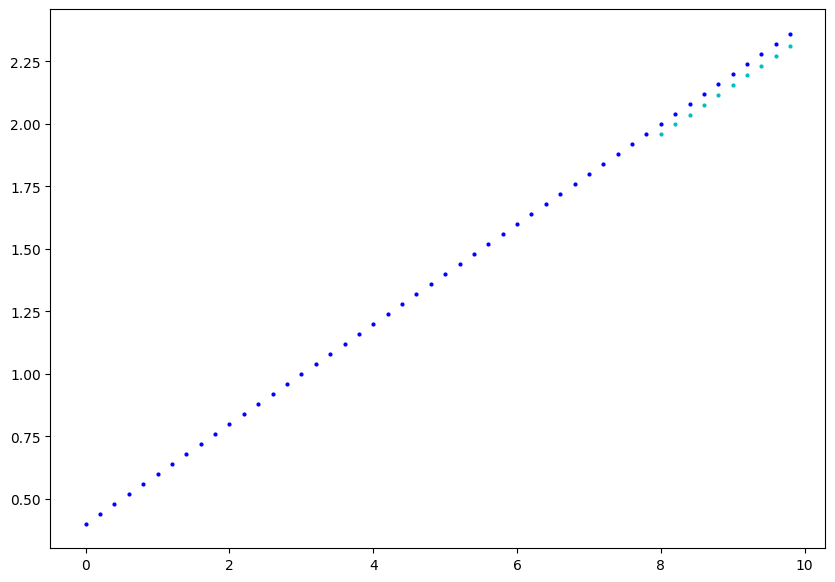

In [132]:
plt.figure(figsize=(10,7))
plt.scatter(X, y, c="b",
            s=4, label="Training data")
plt.scatter(X_test, test_pred, c="c",
            s=4, label="Training data")
plt.show()